In [1]:
# 1. Clone the repo
!git clone https://github.com/fastai/course-v3.git

# 2. Move the exp folder to your current directory
!mv course-v3/nbs/dl2/exp .

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 31.63 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.


In [22]:
from exp.nb_06 import *

In [23]:
import os
import urllib.request

In [24]:
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/mnist.pkl.gz


In [25]:
with gzip.open(path, 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

In [26]:
def get_data(path):
    # path = datasets.download_data(MNIST_URL, ext='.gz')
    with gzip.open(path, 'rb') as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')
    return map(tensor, (x_train,y_train,x_valid,y_valid))

---

## ConvNet
Let's get the data and training interface from where we left in the last notebook.

In [27]:
x_train,y_train,x_valid,y_valid = get_data(path)

x_train,x_valid = normalize_to(x_train,x_valid)
train_ds,valid_ds = Dataset(x_train, y_train),Dataset(x_valid, y_valid)

nh,bs = 50,512
c = y_train.max().item()+1
loss_func = F.cross_entropy

data = DataBunch(*get_dls(train_ds, valid_ds, bs), c)

In [28]:
mnist_view = view_tfm(1,28,28)
cbfs = [Recorder,
        partial(AvgStatsCallback,accuracy),
        CudaCallback,
        partial(BatchTransformXCallback, mnist_view)]

In [29]:
nfs = [8,16,32,64,64]

In [30]:
learn,run = get_learn_run(nfs, data, 0.4, conv_layer, cbs=cbfs)

In [31]:
%time run.fit(2, learn)

train: [1.12482203125, tensor(0.6351, device='cuda:0')]
valid: [0.17290679931640626, tensor(0.9462, device='cuda:0')]
train: [0.218816328125, tensor(0.9341, device='cuda:0')]
valid: [0.1222354736328125, tensor(0.9606, device='cuda:0')]
CPU times: user 1.64 s, sys: 3.09 ms, total: 1.64 s
Wall time: 1.59 s


## Batchnorm
### Custom
Let's start by building our own BatchNorm layer from scratch.

In [32]:
class BatchNorm(nn.Module):
    def __init__(self, nf, mom=0.1, eps=1e-5):
        super().__init__()
        # NB: pytorch bn mom is opposite of what you'd expect
        self.mom,self.eps = mom,eps
        self.mults = nn.Parameter(torch.ones (nf,1,1))
        self.adds  = nn.Parameter(torch.zeros(nf,1,1))
        self.register_buffer('vars',  torch.ones(1,nf,1,1))
        self.register_buffer('means', torch.zeros(1,nf,1,1))

    def update_stats(self, x):
        m = x.mean((0,2,3), keepdim=True)
        v = x.var ((0,2,3), keepdim=True)
        self.means.lerp_(m, self.mom)
        self.vars.lerp_ (v, self.mom)
        return m,v

    def forward(self, x):
        if self.training:
            with torch.no_grad(): m,v = self.update_stats(x)
        else: m,v = self.means,self.vars
        x = (x-m) / (v+self.eps).sqrt()
        return x*self.mults + self.adds

get the mean & variance - we do so by calling `update_stats`:
- `m,v = self.update_stats(x)`

we then subtract the mean & subtract by the sqrt of the variance:
- `x = (x-m) / (v+self.eps).sqrt()`

here we call the gamma & beta params `mults` & `adds`:
- `return x*self.mults + self.adds`

we multiply by a parameter which is initially just a bunch of ones (so does nothing) and add a parameter which is initially just a bunch of zeros (does nothing):
```
        self.mults = nn.Parameter(torch.ones (nf,1,1))
        self.adds  = nn.Parameter(torch.zeros(nf,1,1))
```

as they're parameters they can learn
- adds is just identical to bias

Q: What happens at inference time?
- during training we normalize, but if we do so the same way at inference time if we get a totally different kind of image we might remove all of the things that're interesting about it.
- while we're training we keep an exponentially weighted moving avg of the means & vars - we've got a running avg of the last few batches means/vars
- so then at inference time we use that running avg mean & var

we do so by:

```
        self.register_buffer('vars',  torch.ones(1,nf,1,1))
        self.register_buffer('means', torch.zeros(1,nf,1,1))
```
that creates something called `self.vars`

almost exactly the same as doing self.vars = torch.ones` but does a couple nice things:
- if we move the model to the gpu; anything that's registered as a buffer will be moved to the gpu also
  - otherwise we'd get an error as can't add something on gpu to something on cpu
- these vars/means are part of the model, so if we save the model we have to save these also. `register_buffer` causes them to be saved along with everything else in the model




we avg over axes `(0,2,3)` - all of the batches and the x&y coordinates
- so all we're left with is a mean for each channel, or a mean for each filter

`keepdim=True` means it's going to leave an empty unit axis in positions 0,2,3 so it'll broadcast nicely

In [33]:
def conv_layer(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    # No bias needed if using bn
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=not bn),
              GeneralRelu(**kwargs)]
    if bn: layers.append(BatchNorm(nf))
    return nn.Sequential(*layers)

can optionally append a bn layer (`bn=True`). if we do, then we remove the bias layer (`bias=not bn`) because remember the adds in bn just is a bias

In [34]:
def init_cnn_(m, f):
    if isinstance(m, nn.Conv2d):
        f(m.weight, a=0.1)
        if getattr(m, 'bias', None) is not None: m.bias.data.zero_()
    for l in m.children(): init_cnn_(l, f)

def init_cnn(m, uniform=False):
    f = init.kaiming_uniform_ if uniform else init.kaiming_normal_
    init_cnn_(m, f)

def get_learn_run(nfs, data, lr, layer, cbs=None, opt_func=None, uniform=False, **kwargs):
    model = get_cnn_model(data, nfs, layer, **kwargs)
    init_cnn(model, uniform=uniform)
    return get_runner(model, data, lr=lr, cbs=cbs, opt_func=opt_func)

We can then use it in training and see how it helps keep the activations means to 0 and the std to 1.

In [35]:
learn,run = get_learn_run(nfs, data, 0.9, conv_layer, cbs=cbfs)

train: [0.251212265625, tensor(0.9214, device='cuda:0')]
valid: [0.11911297607421875, tensor(0.9651, device='cuda:0')]


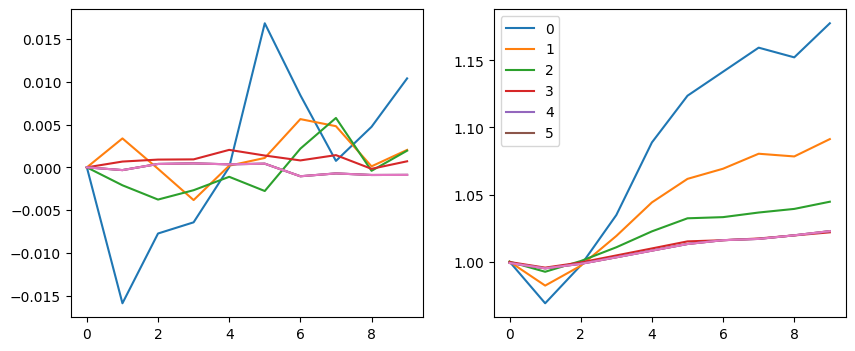

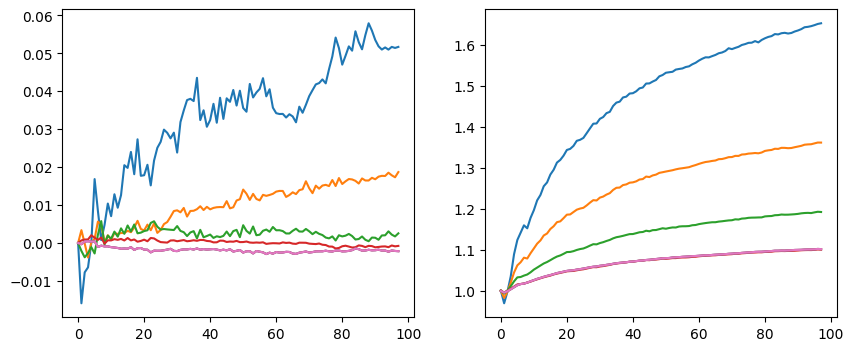

In [36]:
with Hooks(learn.model, append_stats) as hooks:
    run.fit(1, learn)
    fig,(ax0,ax1) = plt.subplots(1,2, figsize=(10,4))
    for h in hooks[:-1]:
        ms,ss = h.stats
        ax0.plot(torch.stack(ms[:10]).cpu())
        ax1.plot(torch.stack(ss[:10]).cpu())
        h.remove()
    plt.legend(range(6));
    plt.show()

    fig,(ax0,ax1) = plt.subplots(1,2, figsize=(10,4))
    for h in hooks[:-1]:
        ms,ss = h.stats
        ax0.plot(torch.stack(ms).cpu())
        ax1.plot(torch.stack(ss).cpu())
    plt.show()

can see our mean starts at exactly 0, and std at exactly 1

notice: our training has entirely removed the exponential growth & sudden crashes that we had previously :)

this is looking a lot better than anything we've had

can get up to lr 1 and 97% acc after 3 epochs

## Builtin batchnorm
can now use PyTorch batchnorm

In [37]:
def conv_layer(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=not bn),
              GeneralRelu(**kwargs)]
    if bn: layers.append(nn.BatchNorm2d(nf, eps=1e-5, momentum=0.1))
    return nn.Sequential(*layers)

In [38]:
learn,run = get_learn_run(nfs, data, 1., conv_layer, cbs=cbfs)

In [39]:
%time run.fit(3, learn)

train: [0.23280494140625, tensor(0.9272, device='cuda:0')]
valid: [0.109577685546875, tensor(0.9643, device='cuda:0')]
train: [0.0694959228515625, tensor(0.9782, device='cuda:0')]
valid: [0.0696177001953125, tensor(0.9790, device='cuda:0')]
train: [0.0439271142578125, tensor(0.9858, device='cuda:0')]
valid: [0.06171813354492187, tensor(0.9806, device='cuda:0')]
CPU times: user 2.68 s, sys: 41.7 ms, total: 2.72 s
Wall time: 2.58 s


## With scheduler
Now let's add the usual warm-up/annealing.

lets try going up to a lr of 2

In [40]:
sched = combine_scheds([0.3, 0.7], [sched_lin(0.6, 2.), sched_lin(2., 0.1)])

In [41]:
learn,run = get_learn_run(nfs, data, 0.9, conv_layer, cbs=cbfs
                          +[partial(ParamScheduler,'lr', sched)])

In [42]:
run.fit(8, learn)

train: [0.2280499609375, tensor(0.9319, device='cuda:0')]
valid: [0.11233133544921875, tensor(0.9665, device='cuda:0')]
train: [0.082213232421875, tensor(0.9742, device='cuda:0')]
valid: [0.13442540283203125, tensor(0.9565, device='cuda:0')]
train: [0.0550488232421875, tensor(0.9824, device='cuda:0')]
valid: [0.07033079833984375, tensor(0.9790, device='cuda:0')]
train: [0.03382499755859375, tensor(0.9891, device='cuda:0')]
valid: [0.0724123779296875, tensor(0.9786, device='cuda:0')]
train: [0.021203837890625, tensor(0.9932, device='cuda:0')]
valid: [0.04925579833984375, tensor(0.9856, device='cuda:0')]
train: [0.01252799072265625, tensor(0.9965, device='cuda:0')]
valid: [0.04614491882324219, tensor(0.9872, device='cuda:0')]
train: [0.007240457763671875, tensor(0.9983, device='cuda:0')]
valid: [0.042979913330078126, tensor(0.9880, device='cuda:0')]
train: [0.0048661483764648435, tensor(0.9993, device='cuda:0')]
valid: [0.04304754638671875, tensor(0.9879, device='cuda:0')]


## More norms
### Layer norm
From the paper: "batch normalization cannot be applied to online learning tasks or to extremely large distributed models where the minibatches have to be small".

online learning tasks; bs=1, getting a single item at a time and learning from that item
- what's the var of that batch? Infinite - so we can't use batch norm in that case

what about a segmentation task of 2 or 4; problem - because across all of our layers, training, the channels; with a bs=2 at some point those 2 values are going to be the same or nearly the save
- so when we then divide by that variance of approx. 0 -> we get infinity

problem: any time you have a small batch size; going to get unstable or impossible training

it's also going to be really hard for RNNs

**Layer normalization** suggests a solution to this




The difference with BatchNorm is
1. we don't keep a moving average
2. we don't average over the batches dimension but over the hidden dimension, so it's independent of the batch size

In [43]:
class LayerNorm(nn.Module):
    __constants__ = ['eps']
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.mult = nn.Parameter(tensor(1.))
        self.add  = nn.Parameter(tensor(0.))

    def forward(self, x):
        m = x.mean((1,2,3), keepdim=True)
        v = x.var ((1,2,3), keepdim=True)
        x = (x-m) / ((v+self.eps).sqrt())
        return x*self.mult + self.add

the same as bn, but here we have `x.mean((1,2,3),...)` opposed to `(0,2,3)` and you removed all the running averages

the reason we don't need the running avgs anymore; because we're not taking the mean across all the items in the batch, every image has its own mean & std, so there's no concept of having to avg across things in a batch

we avg over the channels,x,y for each image individually


In [44]:
def conv_ln(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=True),
              GeneralRelu(**kwargs)]
    if bn: layers.append(LayerNorm())
    return nn.Sequential(*layers)


the problem is when we do that & train (even at a lower lr of `0.8`) it doesn't work

layer norm helps, but it's nowhere near as good as batch norm

In [45]:
learn,run = get_learn_run(nfs, data, 0.8, conv_ln, cbs=cbfs)

In [46]:
%time run.fit(3, learn)

train: [nan, tensor(0.1592, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
train: [nan, tensor(0.0986, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
train: [nan, tensor(0.0986, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
CPU times: user 2.9 s, sys: 19.6 ms, total: 2.92 s
Wall time: 2.87 s


**Thought experiment: can this distinguish foggy days from sunny days (assuming you're using it before the first conv)?**

foggy days will have less activations on avg - because they're less bright and they will have less contrast (aka; they will have lower variance)

so layer norm would cause the variances to be normalized to be the same and the means to be normalized to be the same; now the sunny day & hazy day picture would have the same overall kind of activations and amount of contrast

**A:** No you couldn't - with layer norm you would literally not be able to tell the difference

it's not only if you put the layer norm on the input data (which you wouldn't) but anywhere in the middle layers it's the same, anywhere where the overall activations or amount of difference of activation is something that is part of what you care about, it throws it away (designed to throw it away)

furthermore, if your inference time is using things from a different distribution where that different distribution is important; it throws that away.



## Instance norm

From the paper:

The key difference between contrast and batch normalization is that the latter applies the normalization to a whole batch of images instead for single ones

it wasn't designed for classification, but for style transfer - turned out to work really well for that
- have got to be careful/know what each is for to understand whether it's going to work


basically the same thing as layer norm, but now it's `(2,3)`

In [47]:
class InstanceNorm(nn.Module):
    __constants__ = ['eps']
    def __init__(self, nf, eps=1e-0):
        super().__init__()
        self.eps = eps
        self.mults = nn.Parameter(torch.ones (nf,1,1))
        self.adds  = nn.Parameter(torch.zeros(nf,1,1))

    def forward(self, x):
        m = x.mean((2,3), keepdim=True)
        v = x.var ((2,3), keepdim=True)
        res = (x-m) / ((v+self.eps).sqrt())
        return res*self.mults + self.adds

In [48]:
def conv_in(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=True),
              GeneralRelu(**kwargs)]
    if bn: layers.append(InstanceNorm(nf))
    return nn.Sequential(*layers)

In [49]:
learn,run = get_learn_run(nfs, data, 0.1, conv_in, cbs=cbfs)

In [50]:
%time run.fit(3, learn)

/tmp/ipykernel_7661/1839208567.py:11: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  v = x.var ((2,3), keepdim=True)


train: [nan, tensor(0.0986, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
train: [nan, tensor(0.0986, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
train: [nan, tensor(0.0986, device='cuda:0')]
valid: [nan, tensor(0.0991, device='cuda:0')]
CPU times: user 2.94 s, sys: 11.8 ms, total: 2.95 s
Wall time: 2.88 s


Question: why can't this classify anything?

Lost in all those norms? The authors from the group norm paper have you covered:

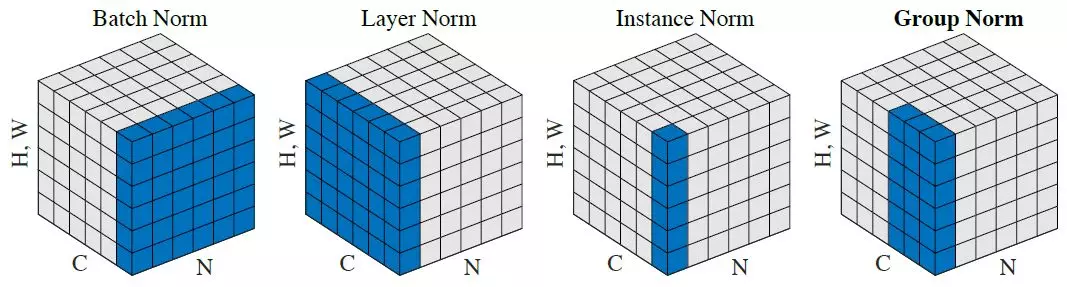

batch norm: avg over the batch, height, width, and is different for each channel

layer norm: avg for each channel, h, w, different for each element of the batch

instance norm: avg over height and width, different for each channel & each batch

group norm: the same as instance norm but arbitrarily group a few channels together

## Group norm
group norm is a more general way to do it

the pytorch docs point out that you can turn it into either instanceNorm or layerNorm depending on how you group things

## Fix small batch sizes
### What's the problem?

When we compute the statistics (mean and std) for a BatchNorm Layer on a small batch, it is possible that we get a standard deviation very close to 0. because there aren't many samples (the variance of one thing is 0. since it's equal to its mean).

In [51]:
data = DataBunch(*get_dls(train_ds, valid_ds, 2), c)

In [52]:
def conv_layer(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=not bn),
              GeneralRelu(**kwargs)]
    if bn: layers.append(nn.BatchNorm2d(nf, eps=1e-5, momentum=0.1))
    return nn.Sequential(*layers)

In [53]:
learn,run = get_learn_run(nfs, data, 0.4, conv_layer, cbs=cbfs)

will notice it takes a long time; small batch sizes take a long time
- lots of kernel launches on the gpu is a lot of overhead

In [54]:
%time run.fit(1, learn)

train: [2.310698125, tensor(0.2064, device='cuda:0')]
valid: [49293197.312, tensor(0.2876, device='cuda:0')]
CPU times: user 1min 12s, sys: 662 ms, total: 1min 12s
Wall time: 1min 13s


## Running Batch Norm
To solve this problem we introduce a Running BatchNorm that uses smoother running mean and variance for the mean and std.

In [55]:
class RunningBatchNorm(nn.Module):
    def __init__(self, nf, mom=0.1, eps=1e-5):
        super().__init__()
        self.mom,self.eps = mom,eps
        self.mults = nn.Parameter(torch.ones (nf,1,1))
        self.adds = nn.Parameter(torch.zeros(nf,1,1))
        self.register_buffer('sums', torch.zeros(1,nf,1,1))
        self.register_buffer('sqrs', torch.zeros(1,nf,1,1))
        self.register_buffer('batch', tensor(0.))
        self.register_buffer('count', tensor(0.))
        self.register_buffer('step', tensor(0.))
        self.register_buffer('dbias', tensor(0.))

    def update_stats(self, x):
        bs,nc,*_ = x.shape
        self.sums.detach_()
        self.sqrs.detach_()
        dims = (0,2,3)
        s = x.sum(dims, keepdim=True)
        ss = (x*x).sum(dims, keepdim=True)
        c = self.count.new_tensor(x.numel()/nc)
        mom1 = 1 - (1-self.mom)/math.sqrt(bs-1)
        self.mom1 = self.dbias.new_tensor(mom1)
        self.sums.lerp_(s, self.mom1)
        self.sqrs.lerp_(ss, self.mom1)
        self.count.lerp_(c, self.mom1)
        self.dbias = self.dbias*(1-self.mom1) + self.mom1
        self.batch += bs
        self.step += 1

    def forward(self, x):
        if self.training: self.update_stats(x)
        sums = self.sums
        sqrs = self.sqrs
        c = self.count
        if self.step<100:
            sums = sums / self.dbias
            sqrs = sqrs / self.dbias
            c    = c    / self.dbias
        means = sums/c
        vars = (sqrs/c).sub_(means*means)
        if bool(self.batch < 20): vars.clamp_min_(0.01)
        x = (x-means).div_((vars.add_(self.eps)).sqrt())
        return x.mul_(self.mults).add_(self.adds)

In [56]:
def conv_rbn(ni, nf, ks=3, stride=2, bn=True, **kwargs):
    layers = [nn.Conv2d(ni, nf, ks, padding=ks//2, stride=stride, bias=not bn),
              GeneralRelu(**kwargs)]
    if bn: layers.append(RunningBatchNorm(nf))
    return nn.Sequential(*layers)

In [57]:
learn,run = get_learn_run(nfs, data, 0.4, conv_rbn, cbs=cbfs)

In [58]:
%time run.fit(1, learn)

train: [0.4604089453125, tensor(0.8748, device='cuda:0')]
valid: [0.169598388671875, tensor(0.9620, device='cuda:0')]
CPU times: user 3min 9s, sys: 808 ms, total: 3min 9s
Wall time: 3min 14s


This solves the small batch size issue!

## What can we do in a single epoch?
Now let's see with a decent batch size what result we can get.

In [59]:
data = DataBunch(*get_dls(train_ds, valid_ds, 32), c)

In [60]:
learn,run = get_learn_run(nfs, data, 0.9, conv_rbn, cbs=cbfs
                          +[partial(ParamScheduler,'lr', sched_lin(1., 0.2))])

In [61]:
%time run.fit(1, learn)

train: [0.157244873046875, tensor(0.9512, device='cuda:0')]
valid: [0.2293028564453125, tensor(0.9690, device='cuda:0')]
CPU times: user 12.3 s, sys: 81.2 ms, total: 12.4 s
Wall time: 12.5 s
